# Network Performance Prediction Project
This project aims to build a Linear Regression model to predict the **Transmission Delay** based on the **Network Load**, using data sourced from Kaggle.

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 1: Loading the Dataset
# We use the raw link from GitHub to ensure the notebook runs automatically
url = 'https://raw.githubusercontent.com/SakhriKarim/Sakhri-Karim-ML-Network-Monitoring/refs/heads/main/Network_Data.csv'
df = pd.read_csv(url)

print("Data loaded successfully. First 5 rows:")
print(df.head())

Data loaded successfully. First 5 rows:
             Timestamp  Signal Strength (dBm)        SNR  Call Duration (s)  \
0  2022-01-03 17:46:13             -84.119763  25.940082        1713.800550   
1  2022-01-04 17:29:31             -87.806131  15.937354         345.371848   
2  2022-01-05 17:14:01            -116.575176  14.709384         259.285043   
3  2022-01-06 16:02:29             -82.961183  21.727165         357.974004   
4  2022-01-07 22:19:17             -85.012574  26.058158         398.006716   

  Environment  Attenuation  Distance to Tower (km)  Tower ID  User ID  \
0       urban    14.690438                2.243176         5       25   
1        home     6.213698                5.002566         3       22   
2        open     4.494415                8.705974         2        5   
3        home     7.619957                7.427025         5       33   
4       urban    10.655159                0.612071         5        8   

  Call Type Incoming/Outgoing  
0      data   

## 1. Exploratory Data Analysis (EDA)
In this section, we visualize the correlation between variables using a Heatmap. This helps us understand the relationship between Network Load and other performance metrics.

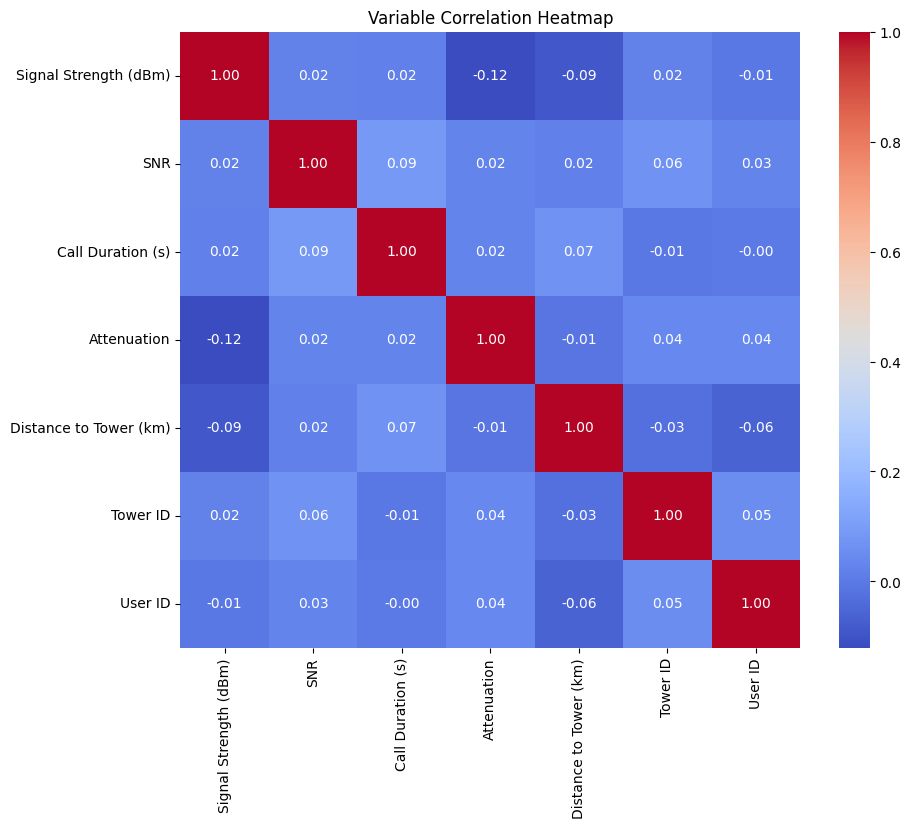

In [21]:
plt.figure(figsize=(10, 8))
# Filtering numeric columns to calculate correlation
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Variable Correlation Heatmap")
plt.show()

## 2. Model Development
We define our independent variable (X) and dependent variable (y). Then, we split the dataset into 80% for training and 20% for testing to evaluate the model's accuracy.

In [22]:
# Selecting feature (Network Load) and target (Transmission Delay)
# Update indices [1] and [2] if your CSV structure is different
X = df[[df.columns[1]]]
y = df[df.columns[2]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Making predictions and calculating performance metrics
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score (R2): {r2:.2f}")

Mean Squared Error (MSE): 31.94
R-squared Score (R2): -0.05


## 3. Visualization of Results
Finally, we plot the regression line against the actual data points. This visualization shows how well the model predicts the transmission delay based on the network load.

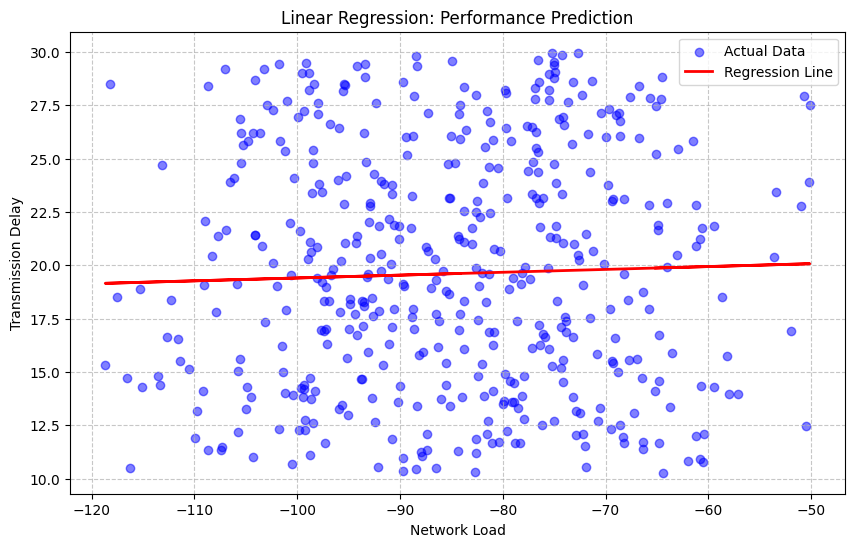

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Actual Data')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')
plt.xlabel('Network Load')
plt.ylabel('Transmission Delay')
plt.title('Linear Regression: Performance Prediction')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 4. Interpretation and Critical Analysis
Based on the visualization above, we observe that the data points are highly scattered and the regression line is relatively flat. This indicates a **weak linear correlation** between the selected features in this specific dataset.

**Technical Explanation:**

1. **Non-Linearity:** Network performance variables, such as transmission delay, are often influenced by complex, non-linear factors like queuing theory and TCP congestion protocols that simple linear regression cannot fully capture.

2. **Network Noise:** The high variance (dispersion) of the blue points suggests significant "noise" in the data, which could be caused by unpredictable background traffic spikes or signal interference.

3. **Complexity:** This result demonstrates that in real-world network monitoring, a single-variable linear model may not be sufficient, and more advanced non-linear or multi-variable models would be required for higher accuracy.